# Cell Composition Visualization

将 Stage 2 输出的 cell 组成数据加载到 ST h5ad 中，并在切片上可视化

Cell composition CSV: /mnt/d/ST_Graduation_Project/SC_MAP_ST/deconv_results/PDAC/PDAC_cell_composition.csv
ST h5ad: /mnt/d/ST_Graduation_Project/database/PDAC/PDAC_ST.h5ad
Output directory: /mnt/d/ST_Graduation_Project/SC_MAP_ST/deconv_results/PDAC/
Output h5ad: /mnt/d/ST_Graduation_Project/SC_MAP_ST/deconv_results/PDAC/PDAC_ST_with_cell_composition.h5ad
Loading ST h5ad data...
ST data shape: (428, 19738)
ST data obs columns: ['array_row', 'array_col', 'x', 'y']
Spatial coordinates: ['10x10', '10x13', '10x14', '10x15', '10x16']

Loading cell composition CSV...
Cell composition shape: (428, 11)
Cell types: ['Acinar cells', 'Cancer', 'Ductal', 'Endothelial cells', 'Mast cells', 'Monocytes', 'RBCs', 'T cells & NK cells', 'Tuft cells', 'mDCs', 'pDCs']

First 5 rows:
       Acinar cells    Cancer    Ductal  Endothelial cells  Mast cells  \
10x10      0.120903  0.272193  0.419230           0.187674         0.0   
10x13      0.000000  0.000000  1.000000           0.000000         0.0   
10x14

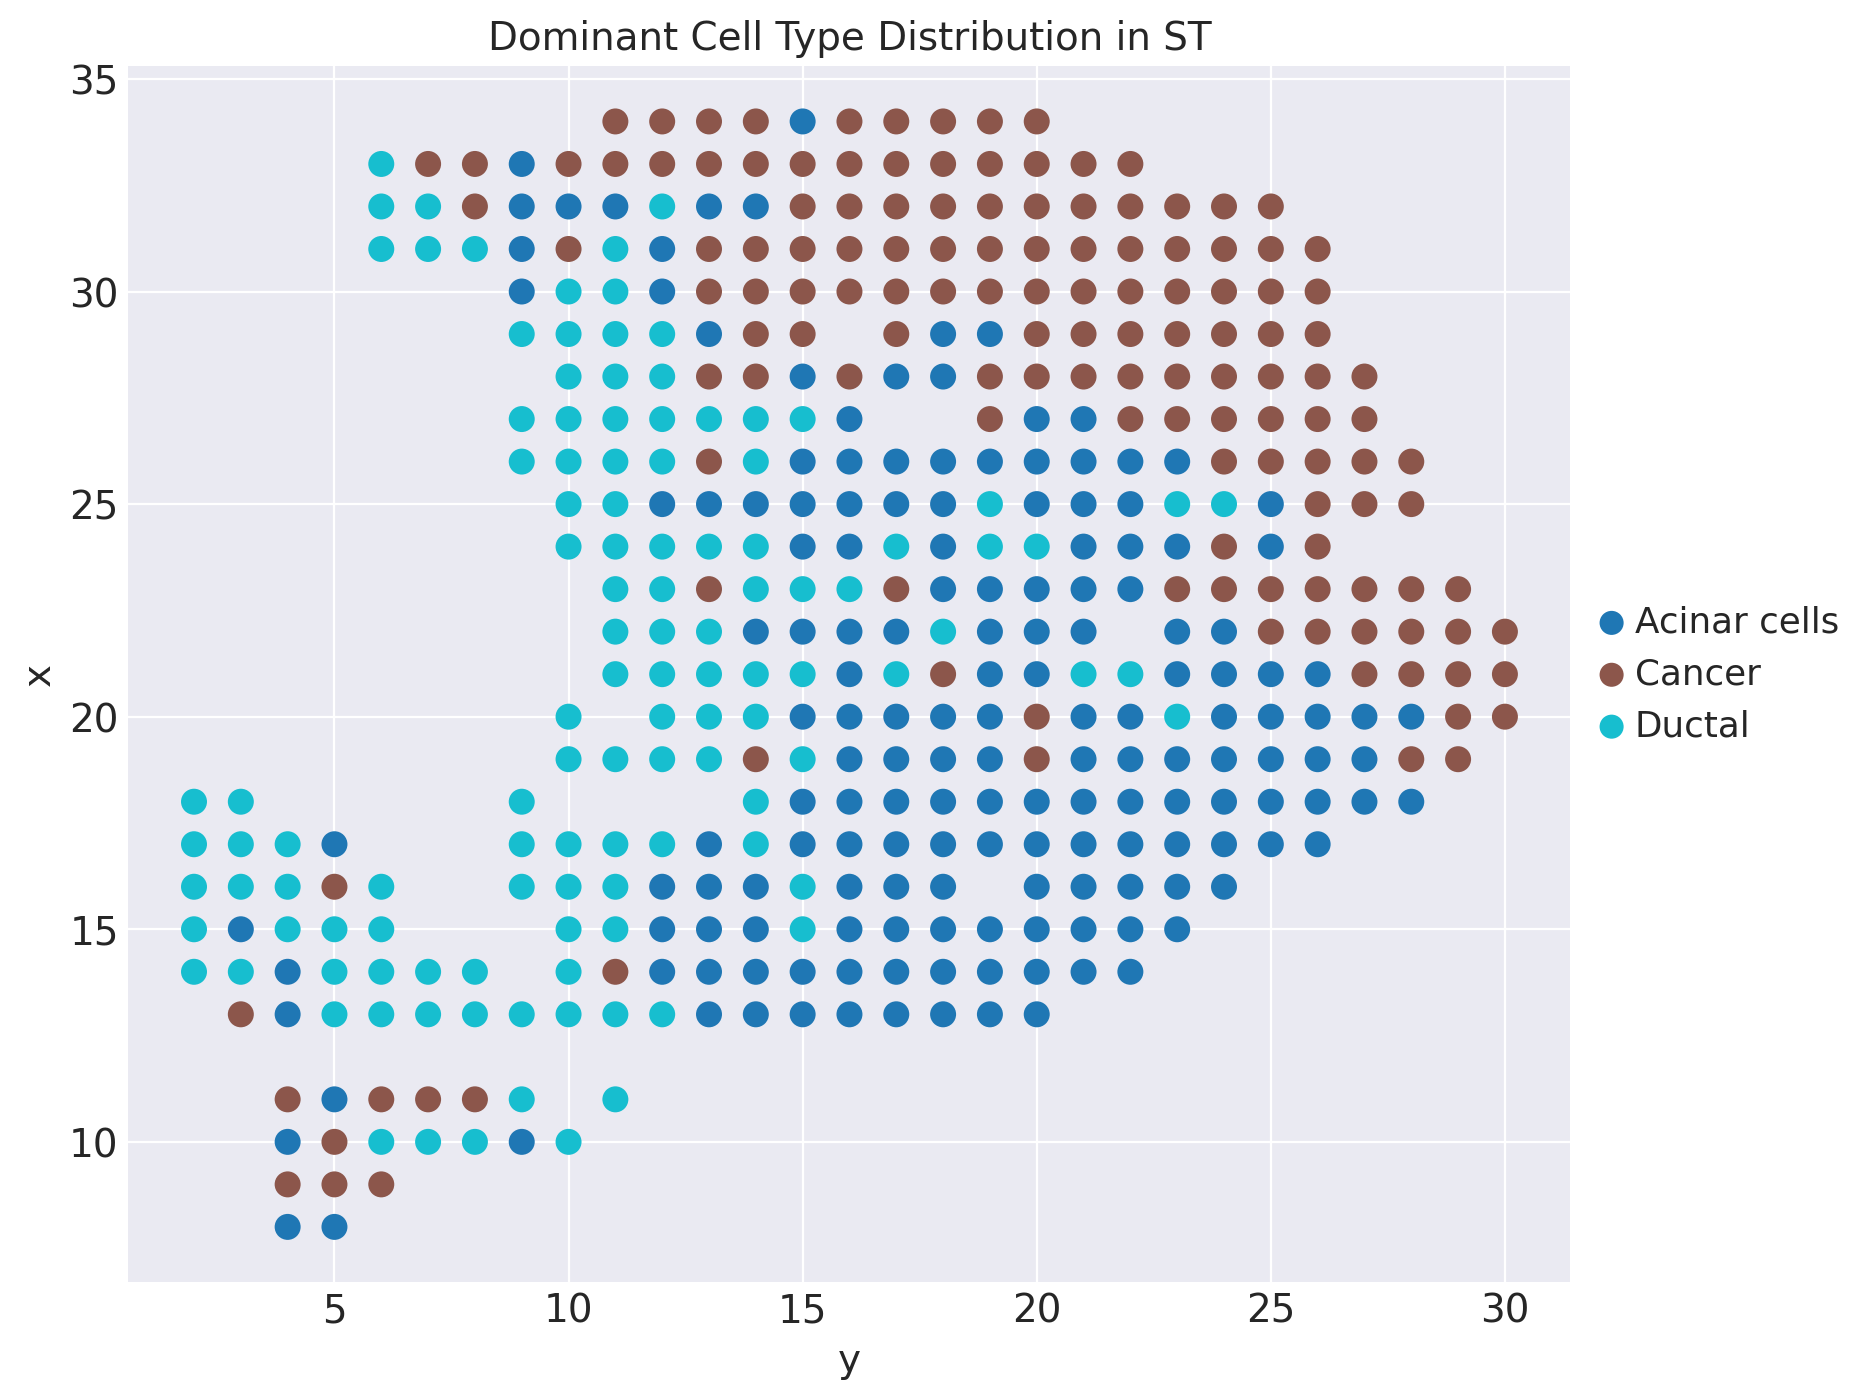

In [157]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sc.set_figure_params(figsize=(8, 8), dpi=100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Cell 组成 CSV 路径
cell_composition_csv = "/mnt/d/ST_Graduation_Project/SC_MAP_ST/deconv_results/PDAC/PDAC_cell_composition.csv"

# ST h5ad 文件路径
st_h5ad_path = "/mnt/d/ST_Graduation_Project/database/PDAC/PDAC_ST.h5ad"

# 输出路径
output_dir = "/mnt/d/ST_Graduation_Project/SC_MAP_ST/deconv_results/PDAC/"
output_h5ad = Path(output_dir) / "PDAC_ST_with_cell_composition.h5ad"

# 可视化参数
figsize = (10, 10)
spot_size = 100

print(f"Cell composition CSV: {cell_composition_csv}")
print(f"ST h5ad: {st_h5ad_path}")
print(f"Output directory: {output_dir}")
print(f"Output h5ad: {output_h5ad}")

# 加载 ST h5ad 数据
print("Loading ST h5ad data...")
adata = sc.read_h5ad(st_h5ad_path)
print(f"ST data shape: {adata.shape}")
print(f"ST data obs columns: {adata.obs.columns.tolist()}")
print(f"Spatial coordinates: {adata.obs_names[:5].tolist()}")

# 加载 cell 组成 CSV
print("\nLoading cell composition CSV...")
cell_composition = pd.read_csv(cell_composition_csv, index_col=0)
print(f"Cell composition shape: {cell_composition.shape}")
print(f"Cell types: {cell_composition.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(cell_composition.head())

# 对齐数据
print("Aligning cell composition data with ST data...")
shared_spots = adata.obs_names.intersection(cell_composition.index)
print(f"共享的 spots: {len(shared_spots)}")

# 重新索引 cell_composition，确保顺序与 adata 一致
cell_composition_aligned = cell_composition.loc[shared_spots]

# 创建一个子集的 adata，只包含有 cell_composition 的 spots
adata_subset = adata[shared_spots].copy()
print(f"\nadata_subset shape: {adata_subset.shape}")
print(f"cell_composition_aligned shape: {cell_composition_aligned.shape}")

# 将 cell 组成添加到 obs
print("Adding cell composition to adata.obs...")

for cell_type in cell_composition_aligned.columns:
    adata_subset.obs[f"cell_comp_{cell_type}"] = cell_composition_aligned[cell_type].values

print(f"\nNew obs columns added: {[col for col in adata_subset.obs.columns if col.startswith('cell_comp_')]}")
print(f"\nadata_subset.obs shape: {adata_subset.obs.shape}")
print(f"\nFirst few rows:")
print(adata_subset.obs[[col for col in adata_subset.obs.columns if col.startswith('cell_comp_')]].head())

# 计算主要 cell type (最高占比)
print("Computing dominant cell type for each spot...")

print("Computing dominant cell type for each spot...")

# 获取所有 cell_comp 列
cell_comp_cols = [col for col in adata_subset.obs.columns if col.startswith('cell_comp_')]

# 创建一个 dataframe 包含所有 cell 组成信息
cell_comp_values = adata_subset.obs[cell_comp_cols].copy()

# 重命名列以去掉 'cell_comp_' 前缀
cell_comp_values.columns = [col.replace('cell_comp_', '') for col in cell_comp_values.columns]

# 找到每行最大值对应的 cell type
dominant_cell_types = cell_comp_values.idxmax(axis=1)
dominant_cell_values = cell_comp_values.max(axis=1)

# 添加到 obs
adata_subset.obs['dominant_cell_type'] = dominant_cell_types.values
adata_subset.obs['dominant_cell_value'] = dominant_cell_values.values

print(f"\n主要 cell types 分布:")
print(adata_subset.obs['dominant_cell_type'].value_counts())
print(f"\n主要 cell type 占比范围: {dominant_cell_values.min():.4f} - {dominant_cell_values.max():.4f}")

print("Creating spatial visualization...")

sc.pl.scatter(
    adata_subset,
    x='y',
    y='x',
    color='dominant_cell_type',
    size=350,
    title='Dominant Cell Type Distribution in ST',
    palette='tab10' 
)


# # 绘图
# sc.pl.spatial(
#     adata_subset,
#     color='dominant_cell_type',
#     size=1.5,
#     title='Dominant Cell Type Distribution in ST',
#     show=True
# )

在组织切片背景上为每个 cell type 绘制空间分布热图
✓ Using hires image, scale factor: 1.0


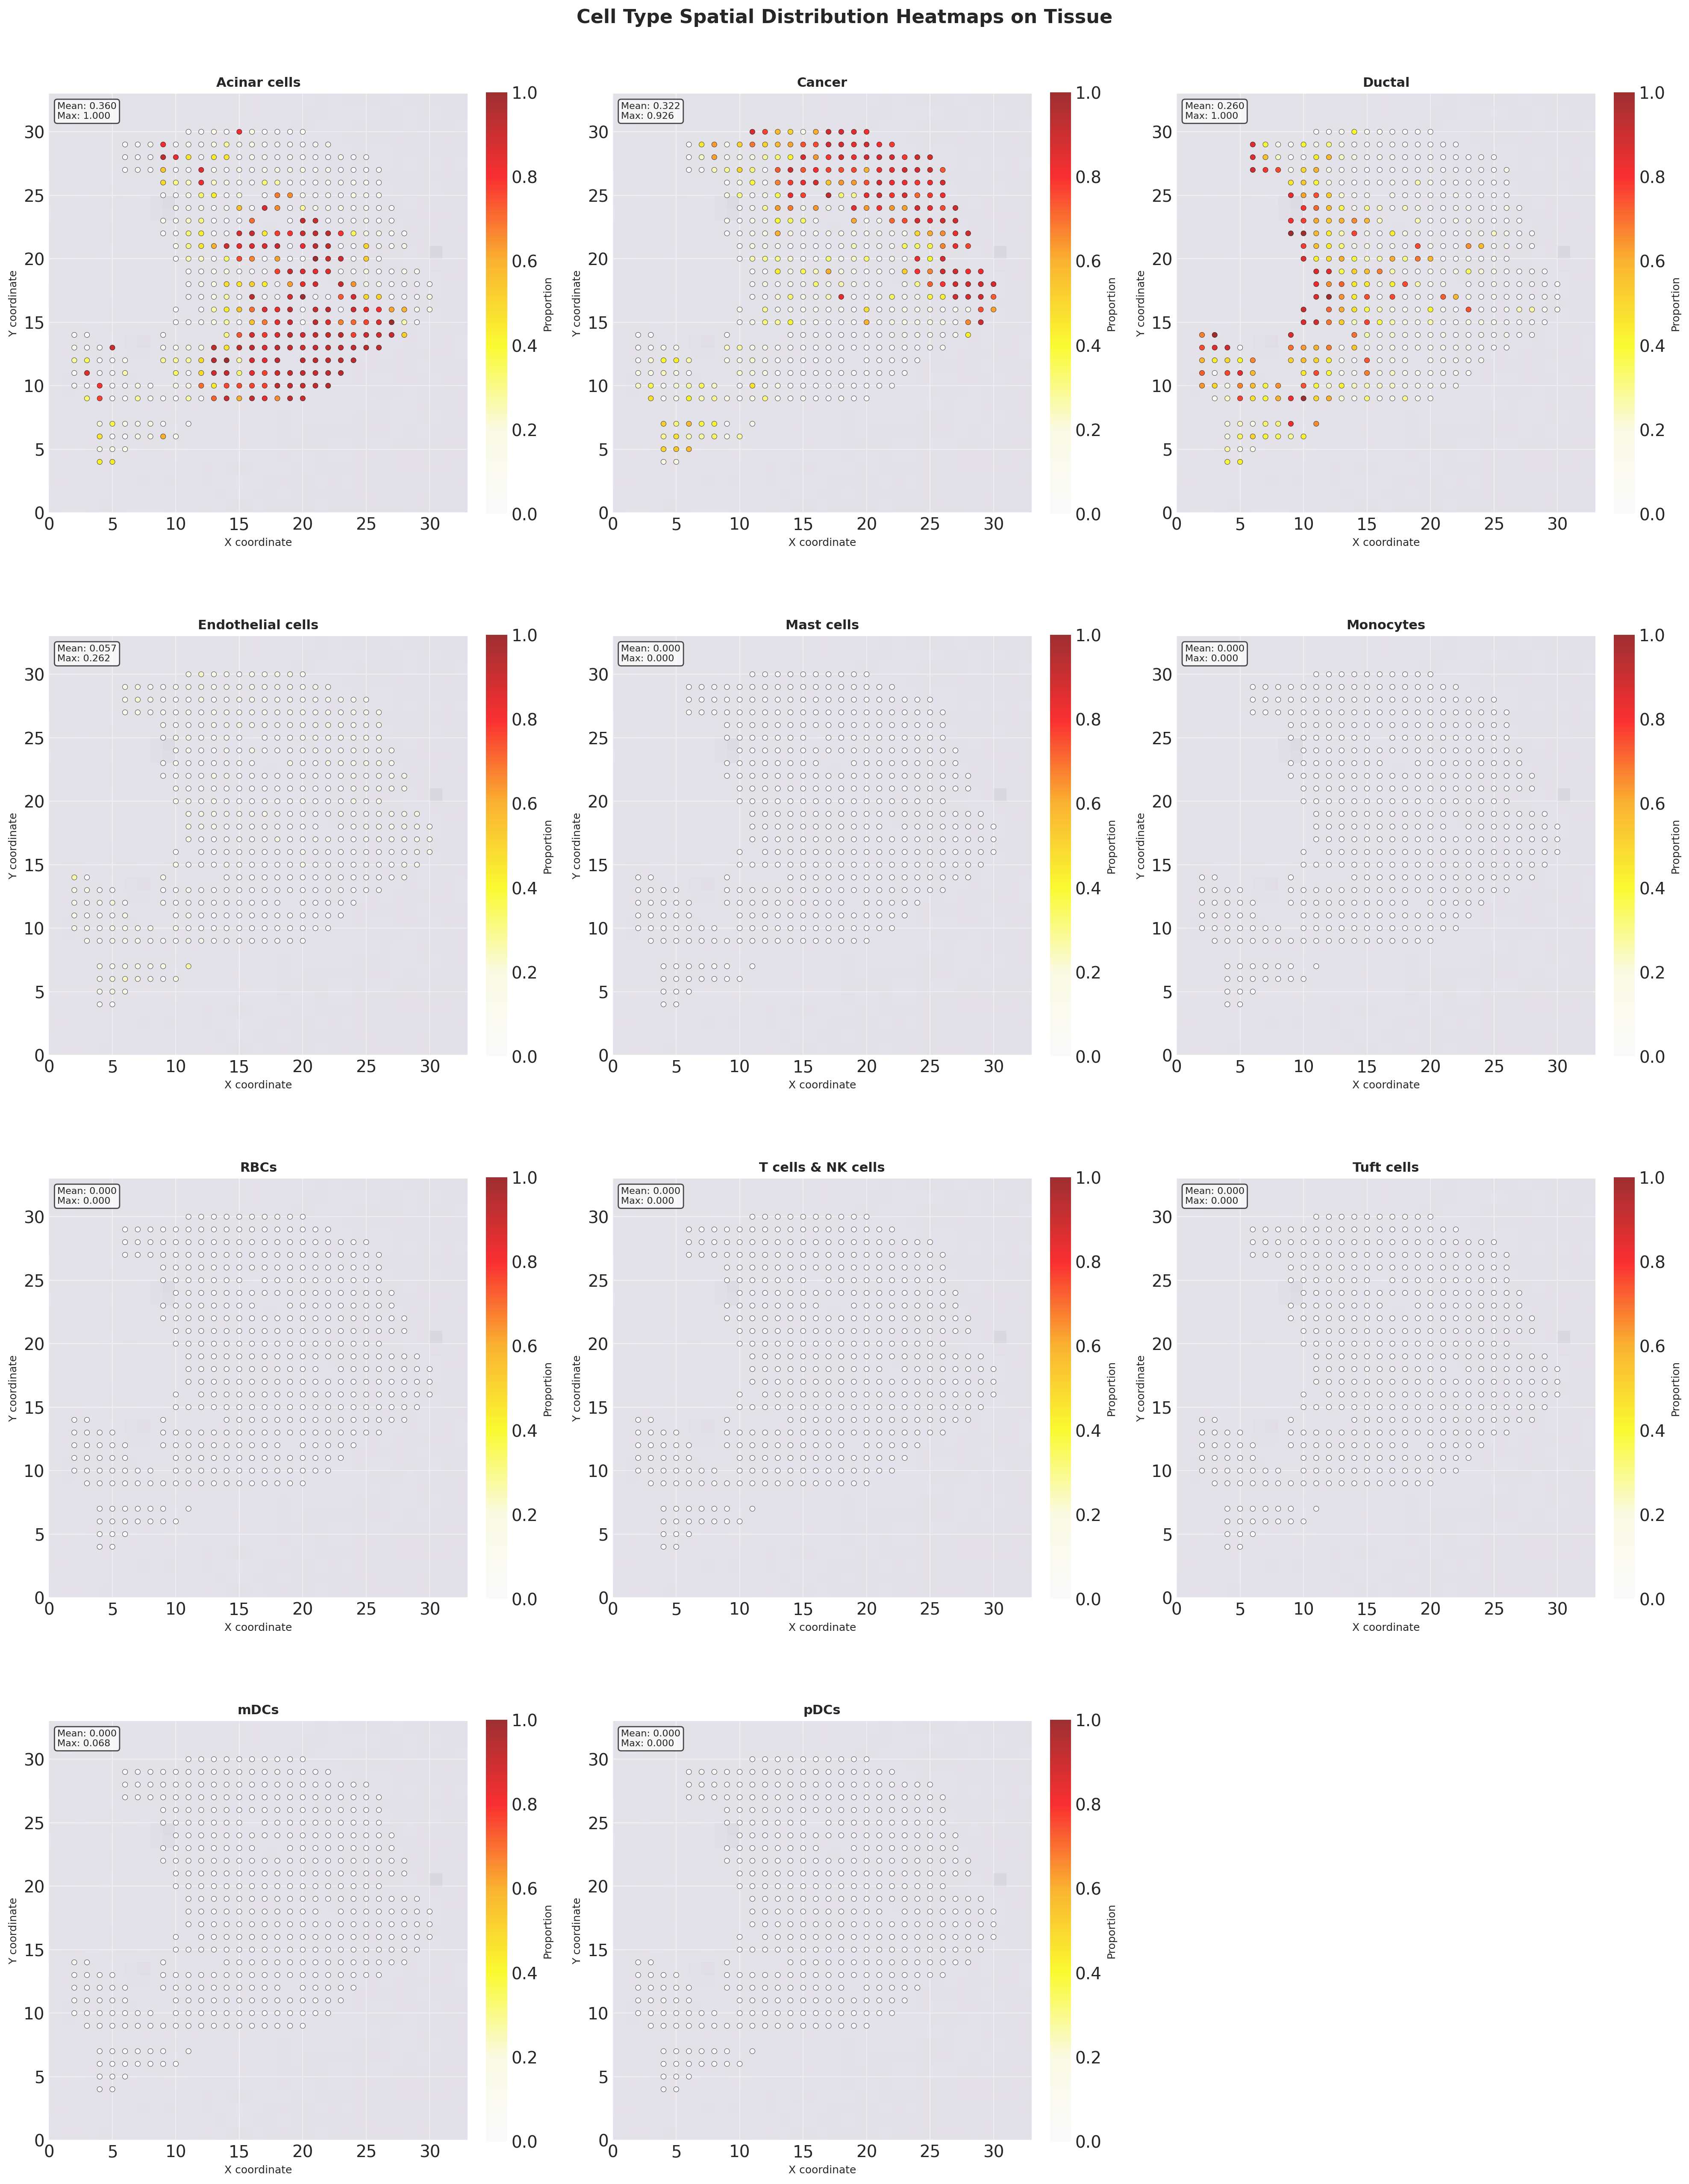

In [158]:
# 在组织切片背景上为每个 cell type 绘制热图
print("="*70)
print("在组织切片背景上为每个 cell type 绘制空间分布热图")
print("="*70)

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

# 获取所有 cell type 列
cell_comp_cols = [col for col in adata_subset.obs.columns if col.startswith('cell_comp_')]
cell_types = [col.replace('cell_comp_', '') for col in cell_comp_cols]

# 获取空间坐标和背景图像
coords = np.array(adata_subset.obsm['spatial'])
# x_raw, y_raw = coords[:, 0], coords[:, 1]
y_raw, x_raw = coords[:, 0], coords[:, 1]
# 获取背景图像和缩放因子
img_array = None
scale_factor = 1.0

if adata_subset.uns.get('spatial'):
    sample_key = list(adata_subset.uns['spatial'].keys())[0]
    spatial_data = adata_subset.uns['spatial'][sample_key]
    
    if 'images' in spatial_data:
        images = spatial_data['images']
        
        if 'hires' in images:
            img_array = np.array(images['hires'])
            scale_factor = spatial_data['scalefactors'].get('tissue_hires_scalef', 1.0)
            print(f"✓ Using hires image, scale factor: {scale_factor}")
        elif 'lowres' in images:
            img_array = np.array(images['lowres'])
            scale_factor = spatial_data['scalefactors'].get('tissue_lowres_scalef', 1.0)
            print(f"✓ Using lowres image, scale factor: {scale_factor}")

# 缩放坐标
x_scaled = x_raw * scale_factor
y_scaled = y_raw * scale_factor

# 计算spot大小
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
dists, _ = nbrs.kneighbors(coords)
median_nn = np.median(dists[:, 1])
spot_size = median_nn * scale_factor * 1.8

# 裁剪图像
if img_array is not None:
    h_orig, w_orig = img_array.shape[:2]
    margin = spot_size * 2
    x_min = max(0, int(x_scaled.min() - margin))
    x_max = min(w_orig, int(x_scaled.max() + margin))
    y_min = max(0, int(y_scaled.min() - margin))
    y_max = min(h_orig, int(y_scaled.max() + margin))
    
    img_cropped = img_array[y_min:y_max, x_min:x_max]
    x_plot = x_scaled - x_min
    y_plot = y_scaled - y_min
else:
    img_cropped = None
    x_plot = x_scaled
    y_plot = y_scaled

# 计算子图布局
n_types = len(cell_types)
n_cols = 3
n_rows = (n_types + n_cols - 1) // n_cols

# 创建大图
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6.5 * n_rows), dpi=100)
axes = axes.flatten() if n_types > 1 else [axes]

# 创建自定义colormap (白色到红色)
colors_list = ['white', 'lightyellow', 'yellow', 'orange', 'red', 'darkred']
n_bins = 256
cmap = LinearSegmentedColormap.from_list('custom', colors_list, N=n_bins)

# 为每个 cell type 绘制热图
for idx, (col, cell_type) in enumerate(zip(cell_comp_cols, cell_types)):
    ax = axes[idx]
    
    # 显示背景图像
    if img_cropped is not None:
        h_crop, w_crop = img_cropped.shape[:2]
        ax.imshow(img_cropped, extent=[0, w_crop, 0, h_crop], 
                 origin='lower', alpha=0.4, zorder=1)
    
    # 获取当前 cell type 的值
    values = adata_subset.obs[col].values
    
    # 绘制散点图 (热图)
    scatter = ax.scatter(x_plot, y_plot, 
                        c=values, 
                        s=spot_size**5, 
                        cmap=cmap,
                        vmin=0,
                        vmax=1,  # 使用95分位数
                        alpha=0.8,
                        edgecolors='black',
                        linewidths=0.3,
                        zorder=10)
    
    # 添加颜色条
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Proportion', fontsize=9)
    
    # 设置坐标轴
    if img_cropped is not None:
        ax.set_xlim(0, w_crop)
        ax.set_ylim(0, h_crop)
    
    ax.set_aspect('equal')
    ax.set_xlabel('X coordinate', fontsize=9)
    ax.set_ylabel('Y coordinate', fontsize=9)
    ax.set_title(f'{cell_type}', fontsize=11, fontweight='bold')
    
    # 添加统计信息
    mean_val = values.mean()
    max_val = values.max()
    ax.text(0.02, 0.98, f'Mean: {mean_val:.3f}\nMax: {max_val:.3f}',
           transform=ax.transAxes, fontsize=8,
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# 隐藏多余的子图
for idx in range(n_types, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Cell Type Spatial Distribution Heatmaps on Tissue', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

# # 保存图像
# output_file = Path(output_dir) / 'cell_type_heatmaps_on_tissue.png'
# fig.savefig(output_file, dpi=300, bbox_inches='tight')
# print(f"\n✓ 已保存组织背景热图到: {output_file}")

plt.show()

# print("\n" + "="*70)
# print("完成！")
# print("="*70)

绘制 Spot Cosine Similarity 热图
Loading cosine similarity from: /mnt/d/ST_Graduation_Project/SC_MAP_ST/stage2_results/PDAC/PDAC_spot_cosine_similarity.csv
Cosine similarity shape: (428, 2)

First 5 rows:
  spot_id  cosine_similarity
0   10x10           0.599851
1   10x13           0.490192
2   10x14           0.449945
3   10x15           0.397413
4   10x16           0.390640

坐标范围:
X: 2 - 30
Y: 8 - 34
Cosine similarity: 0.1637 - 0.7114

Pivot table shape: (26, 29)
Missing values: 326


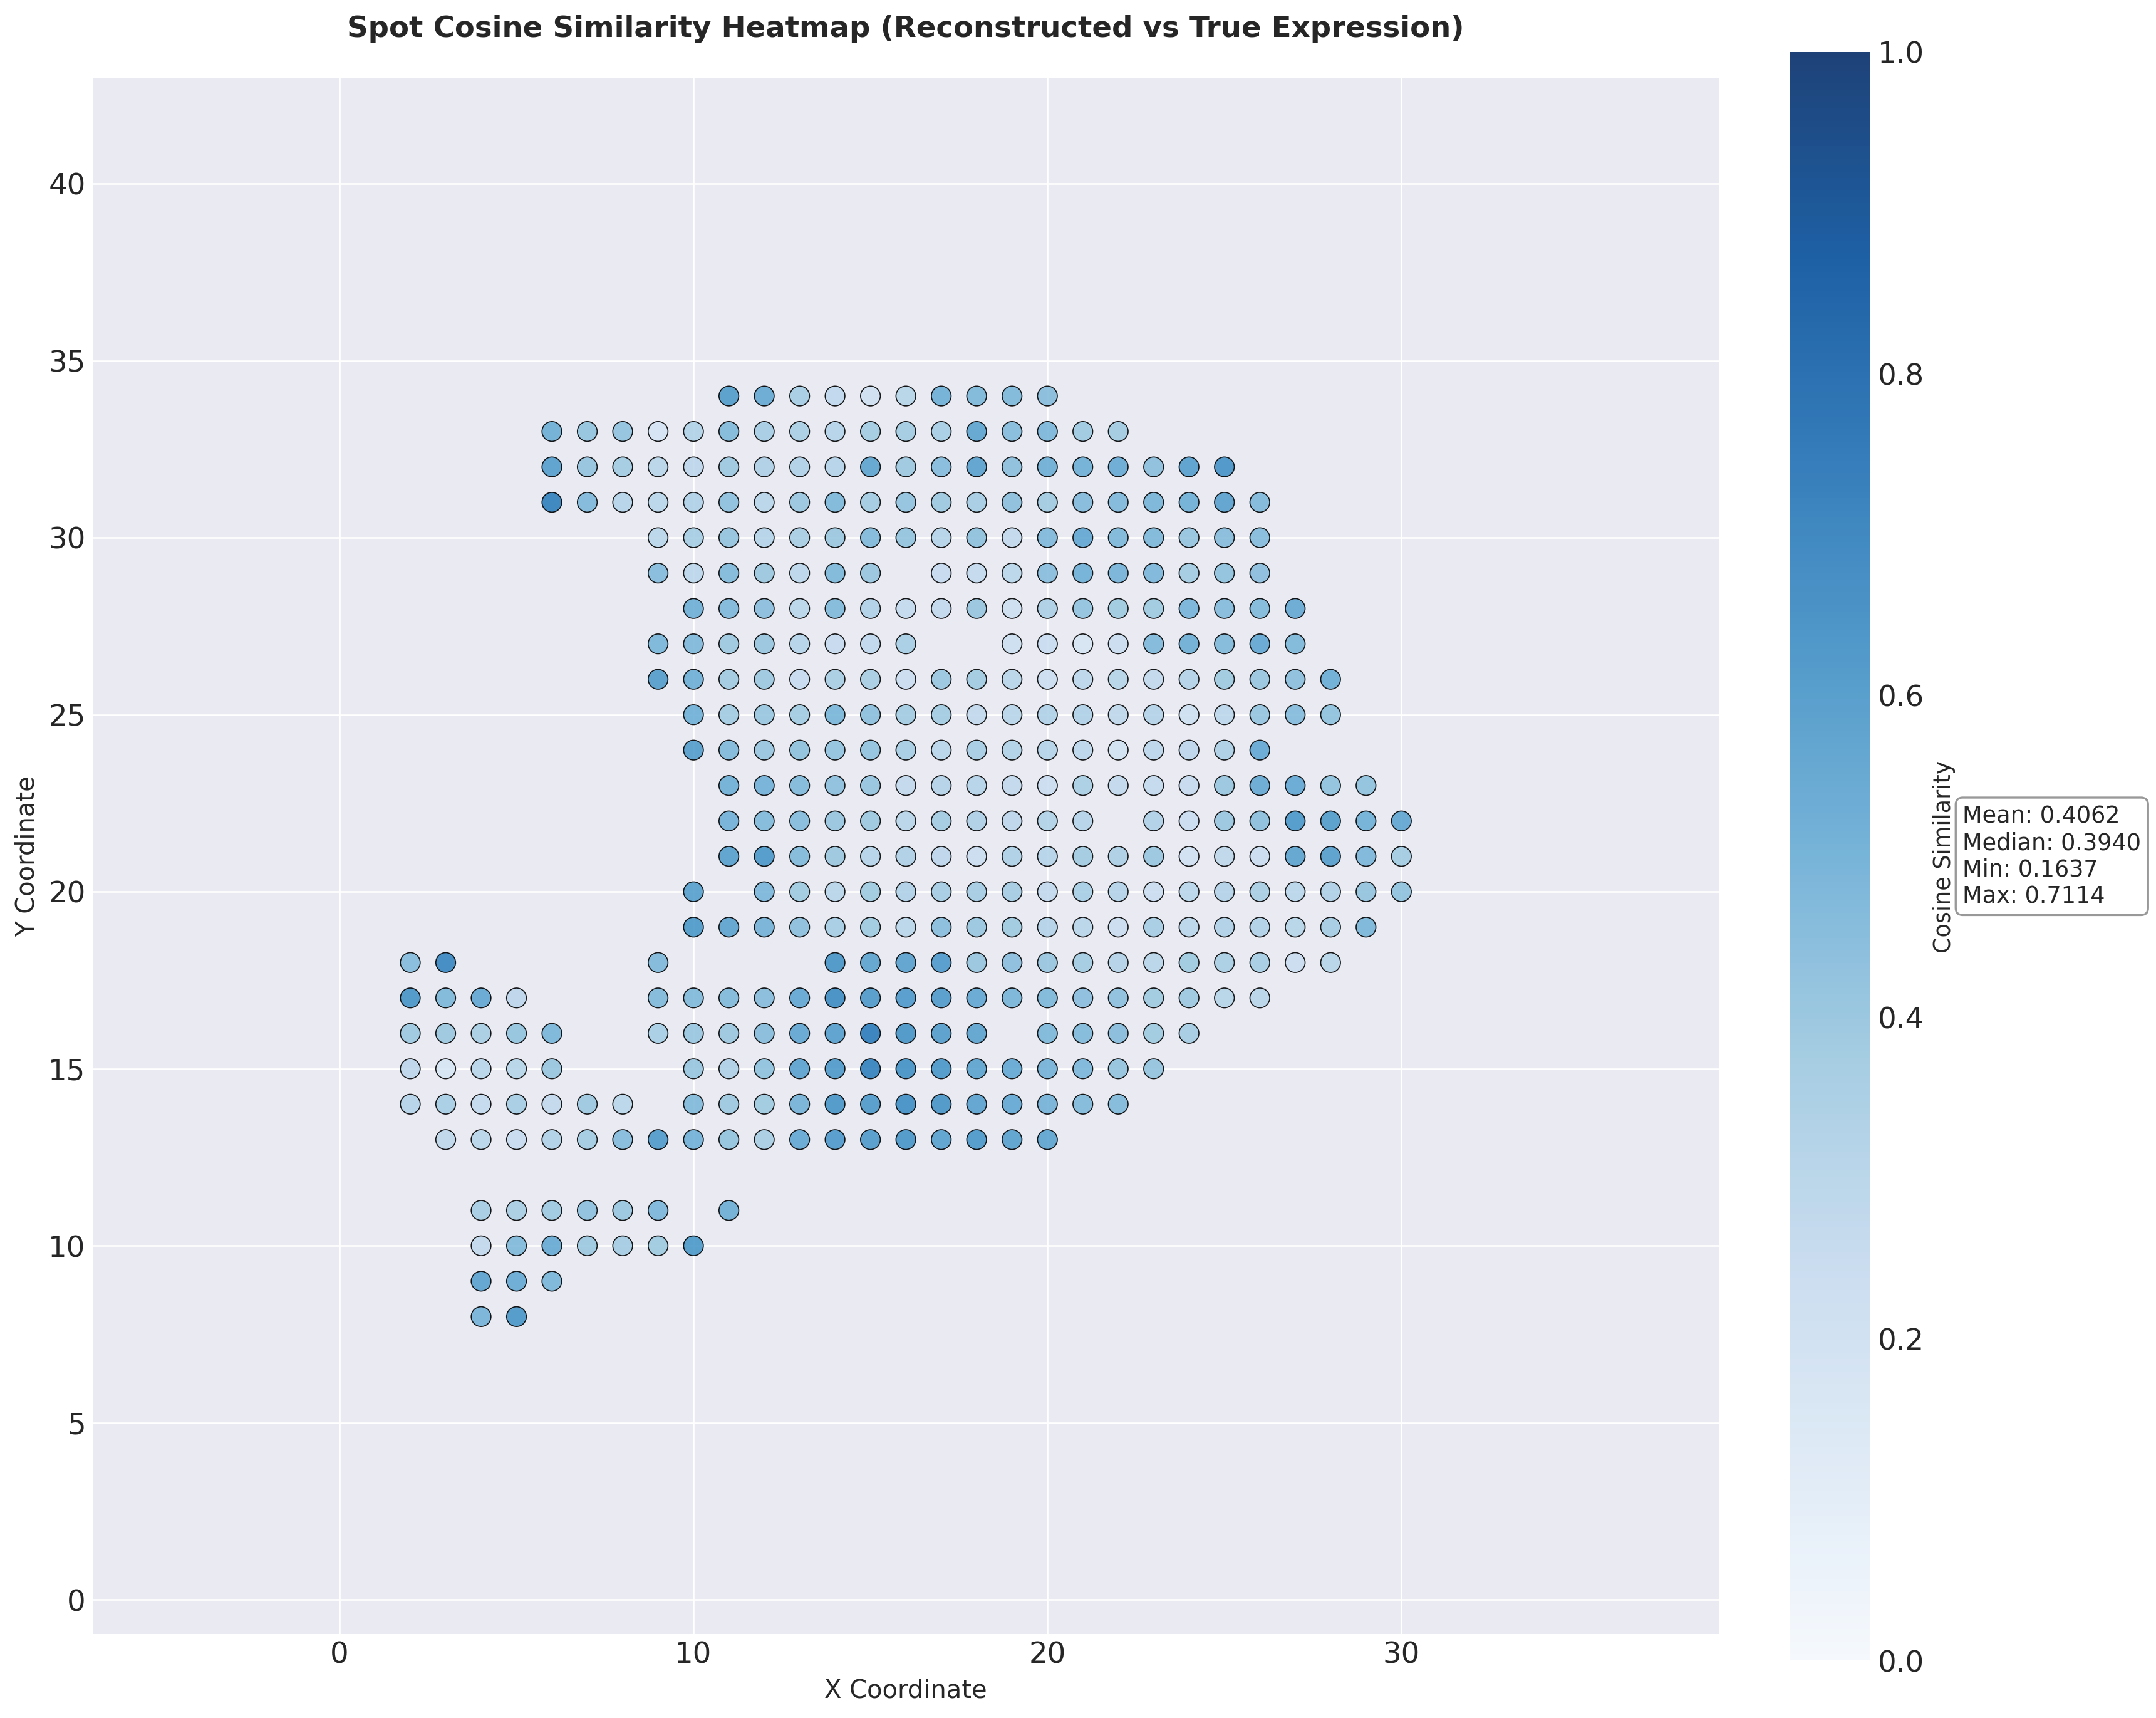

In [159]:
# 绘制 Cosine Similarity 热图
print("="*70)
print("绘制 Spot Cosine Similarity 热图")
print("="*70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 加载 cosine similarity CSV
cosine_csv = "/mnt/d/ST_Graduation_Project/SC_MAP_ST/stage2_results/PDAC/PDAC_spot_cosine_similarity.csv"
print(f"Loading cosine similarity from: {cosine_csv}")

cos_df = pd.read_csv(cosine_csv)
print(f"Cosine similarity shape: {cos_df.shape}")
print(f"\nFirst 5 rows:")
print(cos_df.head())

# 解析 spot_id 获取 x, y 坐标
# spot_id 格式: "XxY" (例如 "10x10")
cos_df['x_coord'] = cos_df['spot_id'].str.split('x').str[0].astype(int)
cos_df['y_coord'] = cos_df['spot_id'].str.split('x').str[1].astype(int)

print(f"\n坐标范围:")
print(f"X: {cos_df['x_coord'].min()} - {cos_df['x_coord'].max()}")
print(f"Y: {cos_df['y_coord'].min()} - {cos_df['y_coord'].max()}")
print(f"Cosine similarity: {cos_df['cosine_similarity'].min():.4f} - {cos_df['cosine_similarity'].max():.4f}")

# 创建透视表 (pivot table) 用于热图
# 行=Y坐标, 列=X坐标, 值=cosine_similarity
pivot_data = cos_df.pivot(index='y_coord', columns='x_coord', values='cosine_similarity')

print(f"\nPivot table shape: {pivot_data.shape}")
print(f"Missing values: {pivot_data.isna().sum().sum()}")

# 创建热图 - 使用圆形散点图
fig, ax = plt.subplots(figsize=(14, 12), dpi=120)

# 获取 x, y 坐标和相似度值
x_coords = cos_df['x_coord'].values
y_coords = cos_df['y_coord'].values
similarity_values = cos_df['cosine_similarity'].values

# 计算spot大小（基于坐标密度）
x_range = x_coords.max() - x_coords.min()
y_range = y_coords.max() - y_coords.min()
spot_size = min(x_range, y_range) / max(len(np.unique(x_coords)), len(np.unique(y_coords))) * 100

# 使用scatter绘制圆形spot
scatter = ax.scatter(
    x_coords, 
    y_coords, 
    c=similarity_values,
    s=spot_size**1,  # 点的大小
    cmap='Blues',
    vmin=0,
    vmax=1,
    alpha=0.9,
    edgecolors='black',
    linewidths=0.5
)

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Cosine Similarity', fontsize=11)

# 设置标题和标签
ax.set_title('Spot Cosine Similarity Heatmap (Reconstructed vs True Expression)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)

# 设置坐标轴范围（添加边距）
margin = spot_size * 0.1
ax.set_xlim(x_coords.min() - margin, x_coords.max() + margin)
ax.set_ylim(y_coords.max() + margin, y_coords.min() - margin)

# 翻转y轴使其从上到下递增
ax.invert_yaxis()

# 设置等比例坐标轴
ax.set_aspect('equal')

# 添加统计信息
mean_cos = cos_df['cosine_similarity'].mean()
median_cos = cos_df['cosine_similarity'].median()
min_cos = cos_df['cosine_similarity'].min()
max_cos = cos_df['cosine_similarity'].max()

stats_text = f'Mean: {mean_cos:.4f}\nMedian: {median_cos:.4f}\nMin: {min_cos:.4f}\nMax: {max_cos:.4f}'
ax.text(1.15, 0.5, stats_text,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()

# # 保存图像
# output_file = Path(output_dir) / 'cosine_similarity_heatmap.png'
# fig.savefig(output_file, dpi=300, bbox_inches='tight')
# print(f"\n✓ 已保存热图到: {output_file}")

plt.show()

# print("\n" + "="*70)
# print("完成！")
# print("="*70)

In [160]:
# sc.pl.spatial(
#     adata_subset,
#     color='Classification',
#     size=1.5,
#     title='Classification in ST',
#     show=True,
#     save=False
# )

In [161]:
# # 在切片上绘制细胞组成饼图 - 带正确的坐标缩放
# from matplotlib.patches import Wedge, Patch
# from sklearn.neighbors import NearestNeighbors
# import numpy as np

# print("="*70)
# print("在切片上绘制 spot 细胞组成饼图（带坐标缩放）")
# print("="*70)

# # 准备数据
# comp_cols = [c for c in adata_subset.obs.columns if c.startswith('cell_comp_')]
# comp_df = adata_subset.obs[comp_cols].copy()
# comp_df.columns = [c.replace('cell_comp_', '') for c in comp_df.columns]

# # 空间坐标（原始坐标）
# coords = np.array(adata_subset.obsm['spatial'])
# x_raw, y_raw = coords[:, 0], coords[:, 1]

# print(f"Cell types: {comp_df.columns.tolist()}")
# print(f"Number of spots: {len(comp_df)}")
# print(f"Original spatial range - X: [{x_raw.min():.1f}, {x_raw.max():.1f}], Y: [{y_raw.min():.1f}, {y_raw.max():.1f}]")

# # 获取scanpy的background image和缩放因子
# print("\n正在获取组织切片图像...")
# img_array = None
# scale_factor = 1.0

# if adata_subset.uns.get('spatial'):
#     sample_key = list(adata_subset.uns['spatial'].keys())[0]
#     spatial_data = adata_subset.uns['spatial'][sample_key]
    
#     print(f"Sample key: {sample_key}")
    
#     # 获取图像和对应的缩放因子
#     if 'images' in spatial_data:
#         images = spatial_data['images']
        
#         # 优先使用hires，否则使用lowres
#         if 'hires' in images:
#             img_array = np.array(images['hires'])
#             scale_factor = spatial_data['scalefactors'].get('tissue_hires_scalef', 1.0)
#             print(f"✓ Using hires image, scale factor: {scale_factor}")
#         elif 'lowres' in images:
#             img_array = np.array(images['lowres'])
#             scale_factor = spatial_data['scalefactors'].get('tissue_lowres_scalef', 1.0)
#             print(f"✓ Using lowres image, scale factor: {scale_factor}")
#         else:
#             img_key = list(images.keys())[0]
#             img_array = np.array(images[img_key])
#             scale_factor = spatial_data['scalefactors'].get('tissue_lowres_scalef', 1.0)
#             print(f"✓ Using {img_key} image, scale factor: {scale_factor}")
        
#         print(f"Original image shape: {img_array.shape}")

# # 使用缩放因子调整坐标
# x_scaled = x_raw * scale_factor
# y_scaled = y_raw * scale_factor

# print(f"\nScale factor: {scale_factor}")
# print(f"Scaled spatial range - X: [{x_scaled.min():.1f}, {x_scaled.max():.1f}], Y: [{y_scaled.min():.1f}, {y_scaled.max():.1f}]")

# # 计算饼图半径（使用缩放后的坐标）
# nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
# dists, _ = nbrs.kneighbors(coords)
# median_nn = np.median(dists[:, 1])
# pie_radius = median_nn * scale_factor * 0.35
# print(f"Pie radius: {pie_radius:.2f}")

# # 颜色映射
# cell_types = comp_df.columns.tolist()
# n_types = len(cell_types)
# cmap = plt.cm.get_cmap('tab20', max(n_types, 3))
# color_map = {ct: cmap(i) for i, ct in enumerate(cell_types)}

# # 裁剪图像到 spot 区域
# print("\n正在裁剪图像...")
# if img_array is not None:
#     h_orig, w_orig = img_array.shape[:2]
    
#     # 计算饼图半径（先计算一下用于边距）
#     nbrs_temp = NearestNeighbors(n_neighbors=2).fit(coords)
#     dists_temp, _ = nbrs_temp.kneighbors(coords)
#     median_nn_temp = np.median(dists_temp[:, 1])
#     pie_radius_temp = median_nn_temp * scale_factor * 0.35
    
#     # 计算裁剪边界（添加边距）
#     margin = pie_radius_temp * 2.5
#     x_min = max(0, int(x_scaled.min() - margin))
#     x_max = min(w_orig, int(x_scaled.max() + margin))
#     y_min = max(0, int(y_scaled.min() - margin))
#     y_max = min(h_orig, int(y_scaled.max() + margin))
    
#     print(f"原始图像: {w_orig}x{h_orig}")
#     print(f"裁剪范围: X[{x_min}:{x_max}], Y[{y_min}:{y_max}]")
    
#     # 裁剪图像
#     img_cropped = img_array[y_min:y_max, x_min:x_max]
#     print(f"裁剪后: {img_cropped.shape[1]}x{img_cropped.shape[0]}")
    
#     # 调整坐标到裁剪后的图像坐标系
#     x_plot = x_scaled - x_min
#     y_plot = y_scaled - y_min
# else:
#     img_cropped = None
#     x_plot = x_scaled
#     y_plot = y_scaled

# # 创建图形
# fig, ax = plt.subplots(figsize=(18, 16), dpi=120)

# # 显示背景切片图（裁剪后的）
# if img_cropped is not None:
#     h_crop, w_crop = img_cropped.shape[:2]
#     print(f"\n显示裁剪后的背景图像 (width={w_crop}, height={h_crop})...")
#     ax.imshow(img_cropped, extent=[0, w_crop, h_crop, 0], origin='upper', alpha=0.3, zorder=1)
#     print(f"✓ Background image displayed")

# # 绘制spot的饼图
# print("\n绘制饼图...")

# # 计算最终的饼图半径
# nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
# dists, _ = nbrs.kneighbors(coords)
# median_nn = np.median(dists[:, 1])
# pie_radius = median_nn * scale_factor * 0.35
# print(f"Pie radius: {pie_radius:.2f}")

# successful_spots = 0
# for spot_idx in range(len(comp_df)):
#     vals = np.array(comp_df.iloc[spot_idx].values, dtype=float)
    
#     # 归一化
#     if vals.sum() > 0:
#         vals = vals / vals.sum()
#     else:
#         continue
    
#     # 跳过全零的spot
#     if vals.max() < 0.01:
#         continue
    
#     # 检查spot是否在裁剪范围内
#     if img_cropped is not None:
#         if x_plot[spot_idx] < 0 or x_plot[spot_idx] >= w_crop or y_plot[spot_idx] < 0 or y_plot[spot_idx] >= h_crop:
#             continue
    
#     # 获取spot坐标（裁剪后图像坐标系中）
#     cx, cy = x_plot[spot_idx], y_plot[spot_idx]
    
#     # 绘制这个spot的饼图
#     start_angle = 0.0
#     for val, cell_type in zip(vals, cell_types):
#         if val <= 0.001:
#             continue
        
#         theta_start = start_angle
#         theta_end = start_angle + val * 360.0
        
#         # 创建wedge
#         wedge = Wedge((cx, cy), pie_radius, theta_start, theta_end,
#                      facecolor=color_map[cell_type], edgecolor='black', 
#                      linewidth=0.3, zorder=10, alpha=0.9)
#         ax.add_patch(wedge)
        
#         start_angle = theta_end
    
#     successful_spots += 1

# print(f"✓ 绘制了 {successful_spots} 个 spot 的饼图")

# # 设置坐标轴（匹配裁剪后的图像范围）
# if img_cropped is not None:
#     h_crop, w_crop = img_cropped.shape[:2]
#     ax.set_xlim(0, w_crop)
#     ax.set_ylim(h_crop, 0)
# else:
#     ax.set_xlim(x_plot.min() - pie_radius * 3, x_plot.max() + pie_radius * 3)
#     ax.set_ylim(y_plot.max() + pie_radius * 3, y_plot.min() - pie_radius * 3)

# ax.set_aspect('equal')
# ax.set_xlabel('X coordinate', fontsize=12)
# ax.set_ylabel('Y coordinate', fontsize=12)

# # 添加图注
# legend_elements = [Patch(facecolor=color_map[ct], edgecolor='black', label=ct) 
#                    for ct in cell_types]
# ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
#          fontsize=20, frameon=True, fancybox=True, shadow=True)

# ax.set_title('Cell Type Composition - Pie Charts on Tissue Slice', 
#             fontsize=14, fontweight='bold', pad=20)

# plt.tight_layout()

# # 保存图像
# output_file = Path(output_dir) / 'spot_pie_charts_on_tissue.png'
# fig.savefig(output_file, dpi=300, bbox_inches='tight')
# print(f"\n✓ 已保存图像到: {output_file}")

# plt.show()

# print("\n" + "="*70)
# print("完成！")
# print("="*70)

In [162]:
# # 绘制 Cluster 组成饼图
# from matplotlib.patches import Wedge, Patch
# from sklearn.neighbors import NearestNeighbors
# import numpy as np

# print("="*70)
# print("在切片上绘制 spot cluster 组成饼图")
# print("="*70)

# # 加载 cluster composition CSV
# cluster_composition_csv = "/mnt/d/ST_Graduation_Project/SC_MAP_ST/stage2_results/GSE243275/GSM7782699_cluster_composition.csv"

# print(f"Loading cluster composition from: {cluster_composition_csv}")
# cluster_comp = pd.read_csv(cluster_composition_csv, index_col=0)
# print(f"Cluster composition shape: {cluster_comp.shape}")
# print(f"Clusters: {cluster_comp.columns.tolist()}")
# print(f"\nFirst 5 rows:")
# print(cluster_comp.head())

# # 对齐数据
# shared_spots = adata.obs_names.intersection(cluster_comp.index)
# print(f"\n共享的 spots: {len(shared_spots)}")

# # 创建子集
# adata_cluster = adata[shared_spots].copy()
# cluster_comp_aligned = cluster_comp.loc[shared_spots]

# # 准备数据
# comp_df = cluster_comp_aligned.copy()
# comp_df.columns = [str(c) for c in comp_df.columns]  # 确保列名是字符串

# # 空间坐标（原始坐标）
# coords = np.array(adata_cluster.obsm['spatial'])
# x_raw, y_raw = coords[:, 0], coords[:, 1]

# print(f"\nClusters: {comp_df.columns.tolist()}")
# print(f"Number of spots: {len(comp_df)}")
# print(f"Original spatial range - X: [{x_raw.min():.1f}, {x_raw.max():.1f}], Y: [{y_raw.min():.1f}, {y_raw.max():.1f}]")

# # 获取背景图像和缩放因子
# print("\n正在获取组织切片图像...")
# img_array = None
# scale_factor = 1.0

# if adata_cluster.uns.get('spatial'):
#     sample_key = list(adata_cluster.uns['spatial'].keys())[0]
#     spatial_data = adata_cluster.uns['spatial'][sample_key]
    
#     print(f"Sample key: {sample_key}")
    
#     if 'images' in spatial_data:
#         images = spatial_data['images']
        
#         if 'hires' in images:
#             img_array = np.array(images['hires'])
#             scale_factor = spatial_data['scalefactors'].get('tissue_hires_scalef', 1.0)
#             print(f"✓ Using hires image, scale factor: {scale_factor}")
#         elif 'lowres' in images:
#             img_array = np.array(images['lowres'])
#             scale_factor = spatial_data['scalefactors'].get('tissue_lowres_scalef', 1.0)
#             print(f"✓ Using lowres image, scale factor: {scale_factor}")
        
#         if img_array is not None:
#             print(f"Original image shape: {img_array.shape}")

# # 使用缩放因子调整坐标
# x_scaled = x_raw * scale_factor
# y_scaled = y_raw * scale_factor

# print(f"\nScale factor: {scale_factor}")
# print(f"Scaled spatial range - X: [{x_scaled.min():.1f}, {x_scaled.max():.1f}], Y: [{y_scaled.min():.1f}, {y_scaled.max():.1f}]")

# # 计算饼图半径
# nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
# dists, _ = nbrs.kneighbors(coords)
# median_nn = np.median(dists[:, 1])
# pie_radius = median_nn * scale_factor * 0.35

# # 颜色映射 - 为clusters使用不同的配色
# clusters = comp_df.columns.tolist()
# n_clusters = len(clusters)
# cmap = plt.cm.get_cmap('tab20', max(n_clusters, 3))
# color_map = {cluster: cmap(i) for i, cluster in enumerate(clusters)}

# # 裁剪图像
# print("\n正在裁剪图像...")
# if img_array is not None:
#     h_orig, w_orig = img_array.shape[:2]
    
#     margin = pie_radius * 2.5
#     x_min = max(0, int(x_scaled.min() - margin))
#     x_max = min(w_orig, int(x_scaled.max() + margin))
#     y_min = max(0, int(y_scaled.min() - margin))
#     y_max = min(h_orig, int(y_scaled.max() + margin))
    
#     print(f"原始图像: {w_orig}x{h_orig}")
#     print(f"裁剪范围: X[{x_min}:{x_max}], Y[{y_min}:{y_max}]")
    
#     img_cropped = img_array[y_min:y_max, x_min:x_max]
#     print(f"裁剪后: {img_cropped.shape[1]}x{img_cropped.shape[0]}")
    
#     x_plot = x_scaled - x_min
#     y_plot = y_scaled - y_min
# else:
#     img_cropped = None
#     x_plot = x_scaled
#     y_plot = y_scaled

# # 创建图形
# fig, ax = plt.subplots(figsize=(18, 16), dpi=120)

# # 显示背景图像
# if img_cropped is not None:
#     h_crop, w_crop = img_cropped.shape[:2]
#     print(f"\n显示裁剪后的背景图像 (width={w_crop}, height={h_crop})...")
#     ax.imshow(img_cropped, extent=[0, w_crop, h_crop, 0], origin='upper', alpha=0.3, zorder=1)
#     print(f"✓ Background image displayed")

# # 绘制饼图
# print("\n绘制cluster饼图...")
# successful_spots = 0

# for spot_idx in range(len(comp_df)):
#     vals = np.array(comp_df.iloc[spot_idx].values, dtype=float)
    
#     # 归一化
#     if vals.sum() > 0:
#         vals = vals / vals.sum()
#     else:
#         continue
    
#     # 跳过全零的spot
#     if vals.max() < 0.01:
#         continue
    
#     # 检查spot是否在裁剪范围内
#     if img_cropped is not None:
#         if x_plot[spot_idx] < 0 or x_plot[spot_idx] >= w_crop or y_plot[spot_idx] < 0 or y_plot[spot_idx] >= h_crop:
#             continue
    
#     # 获取spot坐标
#     cx, cy = x_plot[spot_idx], y_plot[spot_idx]
    
#     # 绘制这个spot的饼图
#     start_angle = 0.0
#     for val, cluster in zip(vals, clusters):
#         if val <= 0.001:
#             continue
        
#         theta_start = start_angle
#         theta_end = start_angle + val * 360.0
        
#         wedge = Wedge((cx, cy), pie_radius, theta_start, theta_end,
#                      facecolor=color_map[cluster], edgecolor='black', 
#                      linewidth=0.3, zorder=10, alpha=0.9)
#         ax.add_patch(wedge)
        
#         start_angle = theta_end
    
#     successful_spots += 1

# print(f"✓ 绘制了 {successful_spots} 个 spot 的cluster饼图")

# # 设置坐标轴
# if img_cropped is not None:
#     h_crop, w_crop = img_cropped.shape[:2]
#     ax.set_xlim(0, w_crop)
#     ax.set_ylim(h_crop, 0)
# else:
#     ax.set_xlim(x_plot.min() - pie_radius * 3, x_plot.max() + pie_radius * 3)
#     ax.set_ylim(y_plot.max() + pie_radius * 3, y_plot.min() - pie_radius * 3)

# ax.set_aspect('equal')
# ax.set_xlabel('X coordinate', fontsize=12)
# ax.set_ylabel('Y coordinate', fontsize=12)

# # 添加图例
# legend_elements = [Patch(facecolor=color_map[cluster], edgecolor='black', label=f'Cluster {cluster}') 
#                    for cluster in clusters]
# ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
#          fontsize=10, frameon=True, fancybox=True, shadow=True, ncol=2)

# ax.set_title('Cluster Composition - Pie Charts on Tissue Slice', 
#             fontsize=14, fontweight='bold', pad=20)

# plt.tight_layout()

# # 保存图像
# output_file = Path(output_dir) / 'spot_cluster_pie_charts_on_tissue.png'
# fig.savefig(output_file, dpi=300, bbox_inches='tight')
# print(f"\n✓ 已保存图像到: {output_file}")

# plt.show()

# print("\n" + "="*70)
# print("完成！")
# print("="*70)